In [23]:
import torch
from torch.utils.data import DataLoader, TensorDataset
import torch.nn as nn
import torch.optim as optim

import numpy as np
import os
import sys

In [22]:
print("Current working directory", os.getcwd() )
print("Directory contents:", os.listdir())

os.chdir("/Users/temp/Documents/Bath University/Msc/Disseration /EEG_Project")
print("Current working directory", os.getcwd() )

Current working directory /Users/temp/Documents/Bath University/Msc/Disseration /EEG_Project/training
Directory contents: ['train_adversatiral.py', '__pycache__', 'train_minimal.py', 'train_standard.py', 'train_minimal.ipynb']
Current working directory /Users/temp/Documents/Bath University/Msc/Disseration /EEG_Project


In [25]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

from models.eegnet import EEGNet  # adjust if necessary
from utils.loaders import get_dataloader
from utils.checks import check_shapes
from utils.preprocessing import preprocess_all_subjects

In [26]:
# ---------- Config ----------
subject_id = 8
batch_size = 32
epochs = 50
lr = 0.001
device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")


In [27]:
# ----------Re run the Preprocessing --------
preprocess_all_subjects(subject_ids=[1, 2, 3, 4, 5, 6, 7])

# ---------- Load Data ----------
dataset = get_dataloader(subject_ids=[1,2,3,4,5,6,7], return_dataset=True)
X, y = dataset.X, dataset.y
print(f"X shape: {X.shape}, y shape: {y.shape}")
print(f"X dtype: {X.dtype}, y dtype: {y.dtype}")
print(f"y unique: {np.unique(y)}")
check_shapes(X, y)

# Ensure y is a NumPy array
y = np.array(y)

preprocessing subject 1 .....
Extracting EDF parameters from /Users/temp/Documents/Bath University/Msc/Disseration /EEG_Project/data/raw/A01T.gdf...
GDF file detected
Setting channel info structure...
Could not determine channel type of the following channels, they will be set as EEG:
EEG-Fz, EEG, EEG, EEG, EEG, EEG, EEG, EEG-C3, EEG, EEG-Cz, EEG, EEG-C4, EEG, EEG, EEG, EEG, EEG, EEG, EEG, EEG-Pz, EEG, EEG, EOG-left, EOG-central, EOG-right
Creating raw.info structure...


/Users/temp/anaconda3/envs/robust_eeg/lib/python3.10/contextlib.py:142: RuntimeWarning: Channel names are not unique, found duplicates for: {'EEG'}. Applying running numbers for duplicates.
  next(self.gen)


Reading 0 ... 672527  =      0.000 ...  2690.108 secs...
NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).
Selected EEG channels: 22
['EEG-Fz', 'EEG-C3', 'EEG-Cz', 'EEG-C4', 'EEG-Pz', 'EEG-0', 'EEG-1', 'EEG-2', 'EEG-3', 'EEG-4', 'EEG-5', 'EEG-6', 'EEG-7', 'EEG-8', 'EEG-9', 'EEG-10', 'EEG-11', 'EEG-12', 'EEG-13', 'EEG-14', 'EEG-15', 'EEG-16']
Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 8 - 30 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 8.00
- Lower transition bandwidth: 2.00 Hz (-6 dB cutoff frequency: 7.00 Hz)
- Upper passband edge: 30.00 Hz
- Upper transition bandwidth: 7.50 Hz (-6 dB cutoff frequency: 33.75 Hz)
- Filter length: 413 samples (1.652 s)



[Parallel(n_jobs=1)]: Done  17 tasks      | elapsed:    0.9s


Used Annotations descriptions: ['1023', '1072', '276', '277', '32766', '768', '769', '770', '771', '772']
Event dict: {'1023': 1, '1072': 2, '276': 3, '277': 4, '32766': 5, '768': 6, '769': 7, '770': 8, '771': 9, '772': 10}
Not setting metadata
288 matching events found


...

Used Annotations descriptions: ['1023', '1072', '276', '277', '32766', '768', '769', '770', '771', '772']
Event dict: {'1023': 1, '1072': 2, '276': 3, '277': 4, '32766': 5, '768': 6, '769': 7, '770': 8, '771': 9, '772': 10}
Not setting metadata
288 matching events found
No baseline correction applied
0 projection items activated
Using data from preloaded Raw for 288 events and 1001 original time points ...
0 bad epochs dropped
preprocessing subject 7 .....
Extracting EDF parameters from /Users/temp/Documents/Bath University/Msc/Disseration /EEG_Project/data/raw/A07T.gdf...
GDF file detected
Setting channel info structure...
Could not determine channel type of the following channels, they will be set as EEG:
EEG-Fz, EEG, EEG, EEG, EEG, EEG, EEG, EEG-C3, EEG, EEG-Cz, EEG, EEG-C4, EEG, EEG, EEG, EEG, EEG, EEG, EEG, EEG-Pz, EEG, EEG, EOG-left, EOG-central, EOG-right
Creating raw.info structure...
Reading 0 ... 681070  =      0.000 ...  2724.280 secs...


[Parallel(n_jobs=1)]: Done  22 out of  22 | elapsed:    1.0s finished
/Users/temp/anaconda3/envs/robust_eeg/lib/python3.10/contextlib.py:142: RuntimeWarning: Channel names are not unique, found duplicates for: {'EEG'}. Applying running numbers for duplicates.
  next(self.gen)


NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).
Selected EEG channels: 22
['EEG-Fz', 'EEG-C3', 'EEG-Cz', 'EEG-C4', 'EEG-Pz', 'EEG-0', 'EEG-1', 'EEG-2', 'EEG-3', 'EEG-4', 'EEG-5', 'EEG-6', 'EEG-7', 'EEG-8', 'EEG-9', 'EEG-10', 'EEG-11', 'EEG-12', 'EEG-13', 'EEG-14', 'EEG-15', 'EEG-16']
Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 8 - 30 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 8.00
- Lower transition bandwidth: 2.00 Hz (-6 dB cutoff frequency: 7.00 Hz)
- Upper passband edge: 30.00 Hz
- Upper transition bandwidth: 7.50 Hz (-6 dB cutoff frequency: 33.75 Hz)
- Filter length: 413 samples (1.652 s)

Used Annotations descriptions: ['1023', '1072', '276', '277', '32766', '768', '769', '770', '771', '772']
Event dict: {'102

[Parallel(n_jobs=1)]: Done  17 tasks      | elapsed:    0.5s
[Parallel(n_jobs=1)]: Done  22 out of  22 | elapsed:    0.6s finished


0 bad epochs dropped
Preprocessing complete
X shape: (2016, 22, 1001), y shape: (2016,)
X dtype: float64, y dtype: int64
y unique: [0 1 2 3]


In [28]:
# Filter out any invalid samples (e.g., negative class labels)
valid_mask = y >= 0
X = X[valid_mask]
y = y[valid_mask]

# Debug: Check what labels look like
print("Original labels:", np.unique(y), "min:", y.min(), "max:", y.max())

# Remap labels to start from 0
unique_labels = np.unique(y)
label_map = {old: new for new, old in enumerate(unique_labels)}
y = np.vectorize(label_map.get)(y)

print("Cleaned labels:", np.unique(y), "min:", y.min(), "max:", y.max())

Original labels: [0 1 2 3] min: 0 max: 3
Cleaned labels: [0 1 2 3] min: 0 max: 3


In [29]:
# ------------- Train test split -------
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Toy dataset
X_small, y_small = [], []
for cls in range(4):
    idx = np.where(y == cls)[0][:30]
    X_small.append(X[idx])
    y_small.append(y[idx])

X_small = np.concatenate(X_small, axis=0)
y_small = np.concatenate(y_small, axis=0)

X_train = np.expand_dims(X_train, axis=1)    # from (N, 22, 1001) → (N, 1, 22, 1001)
X_val = np.expand_dims(X_val, axis=1)        # from (N, 22, 1001) → (N, 1, 22, 1001)

In [30]:
# asserting correct dimensions. good for debugging
assert X_train.shape[1] == 1, "Expected dummy input channel dimension (1)"
assert X_train.shape[2] == 22, "Expected 22 EEG channels"
assert X_train.shape[3] == 1001, "Expected 1001 time samples"
print(f"X shape: {X_small.shape}, y shape: {y_small.shape}")

X shape: (120, 22, 1001), y shape: (120,)


In [31]:
# wrap in Dataloader
train_dataset = TensorDataset(
    torch.tensor(X_train, dtype=torch.float32),
    torch.tensor(y_train, dtype=torch.long)
)
val_dataset = TensorDataset(
    torch.tensor(X_val, dtype=torch.float32),
    torch.tensor(y_val, dtype=torch.long)
)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)



In [32]:
# ---------- Model Setup ----------
model = EEGNet(num_classes=len(torch.unique(torch.tensor(y))), channels=X.shape[1], samples=X.shape[2] ).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=lr)

In [33]:
# ---------- Training Loop ----------
for epoch in range(epochs):
    model.train()
    train_loss = 0.0
    for batch_X, batch_y in train_loader:
        batch_X = batch_X.to(device).float()
        batch_y = batch_y.to(device).long()
        

        optimizer.zero_grad()
        outputs = model(batch_X)
        loss = criterion(outputs, batch_y)
        loss.backward()
        optimizer.step()
        train_loss += loss.item()

    print(f"Epoch [{epoch+1}/{epochs}] - Loss: {train_loss:.4f}")
    
     # Validation
    model.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for batch_x, batch_y in val_loader:
            outputs = model(batch_x.to(device))
            preds = torch.argmax(outputs, dim=1)
            correct += (preds == batch_y.to(device)).sum().item()
            total += batch_y.size(0)
    val_acc = correct / total

    print(f"Epoch [{epoch}/5] - Train Loss: {train_loss:.4f} - Val Acc: {val_acc:.4f}")

print("✅ Training complete.")

   

Epoch [1/50] - Loss: 70.9164
Epoch [0/5] - Train Loss: 70.9164 - Val Acc: 0.2500
Epoch [2/50] - Loss: 68.1241
Epoch [1/5] - Train Loss: 68.1241 - Val Acc: 0.2500
Epoch [3/50] - Loss: 65.7470
Epoch [2/5] - Train Loss: 65.7470 - Val Acc: 0.2500
Epoch [4/50] - Loss: 63.7494
Epoch [3/5] - Train Loss: 63.7494 - Val Acc: 0.3292
Epoch [5/50] - Loss: 61.8416
Epoch [4/5] - Train Loss: 61.8416 - Val Acc: 0.2500
Epoch [6/50] - Loss: 59.9980
Epoch [5/5] - Train Loss: 59.9980 - Val Acc: 0.2698
Epoch [7/50] - Loss: 58.0172
Epoch [6/5] - Train Loss: 58.0172 - Val Acc: 0.2500
Epoch [8/50] - Loss: 56.4790
Epoch [7/5] - Train Loss: 56.4790 - Val Acc: 0.3119
Epoch [9/50] - Loss: 55.3870
Epoch [8/5] - Train Loss: 55.3870 - Val Acc: 0.2500
Epoch [10/50] - Loss: 54.3670
Epoch [9/5] - Train Loss: 54.3670 - Val Acc: 0.2500
Epoch [11/50] - Loss: 52.6742
Epoch [10/5] - Train Loss: 52.6742 - Val Acc: 0.2599
Epoch [12/50] - Loss: 51.0085
Epoch [11/5] - Train Loss: 51.0085 - Val Acc: 0.2946
Epoch [13/50] - Loss: 4

In [34]:
# --- Evaluation ---
model.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for batch_X, batch_y in train_loader:
        batch_X = batch_X.to(device)
        outputs = model(batch_X)
        preds = torch.argmax(outputs, dim=1).cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(batch_y.numpy())

acc = accuracy_score(all_labels, all_preds)
print(f"\n✅ Final Val Accuracy: {acc:.4f}")


✅ Final Val Accuracy: 0.4851


In [35]:

print("Prediction distribution:", np.bincount(all_preds))
print(outputs[:5])  # see if they're all biased to class 0
probs = torch.softmax(outputs, dim=1)
print(probs[0])  # e.g., tensor([0.99, 0.002, 0.002, 0.001])


print("\n🧾 Classification Report:")
print(classification_report(all_labels, all_preds))

print("\n📊 Confusion Matrix:")
print(confusion_matrix(all_labels, all_preds))

Prediction distribution: [1055   78  467   12]
tensor([[ 0.5250, -7.4558,  5.5733, -2.6793],
        [ 4.1670, -0.5660,  3.6256, -6.4320],
        [ 3.6026,  4.0633, -1.8334, -6.9761],
        [ 4.2073,  1.9915, -0.2919, -5.3090],
        [ 0.6115, -2.2111,  1.0190,  0.0493]], device='mps:0')
tensor([6.3777e-03, 2.1808e-06, 9.9336e-01, 2.5885e-04], device='mps:0')

🧾 Classification Report:
              precision    recall  f1-score   support

           0       0.38      1.00      0.55       403
           1       1.00      0.19      0.32       403
           2       0.62      0.72      0.66       403
           3       1.00      0.03      0.06       403

    accuracy                           0.49      1612
   macro avg       0.75      0.49      0.40      1612
weighted avg       0.75      0.49      0.40      1612


📊 Confusion Matrix:
[[403   0   0   0]
 [291  78  34   0]
 [114   0 289   0]
 [247   0 144  12]]


In [ ]:
train_losses = []
val_accuracies = []

for epoch in range(epochs):
    
    model.train()
    running_loss = 0.0
    
    for batch_X, batch_y in train_loader:
        batch_X, batch_y = batch_X.to(device), batch_y.to(device)
        optimizer.zero_grad()
        outputs = model(batch_X)
        loss = criterion(outputs, batch_y)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
        
    train_loss = running_loss / len(train_loader)
    train_losses.append(train_loss)
    
    # validation
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for batch_X, batch_y in val_loader:
           batch_X, batch_y = batch_X.to(device), batch_y.to(device) 
           outputs = model(batch_X)
           _, predicted = torch.max(outputs.data, 1)
           total += batch_y.size(0)
           
           correct += (predicted == batch_y).sum().item()
    
    val_accuracy = correct / total
    val_accuracies.append(val_accuracy)

    print(f"Epoch [{epoch+1}/{epochs}] - Loss: {train_loss:.4f} - Val Acc: {val_accuracy:.4f}")


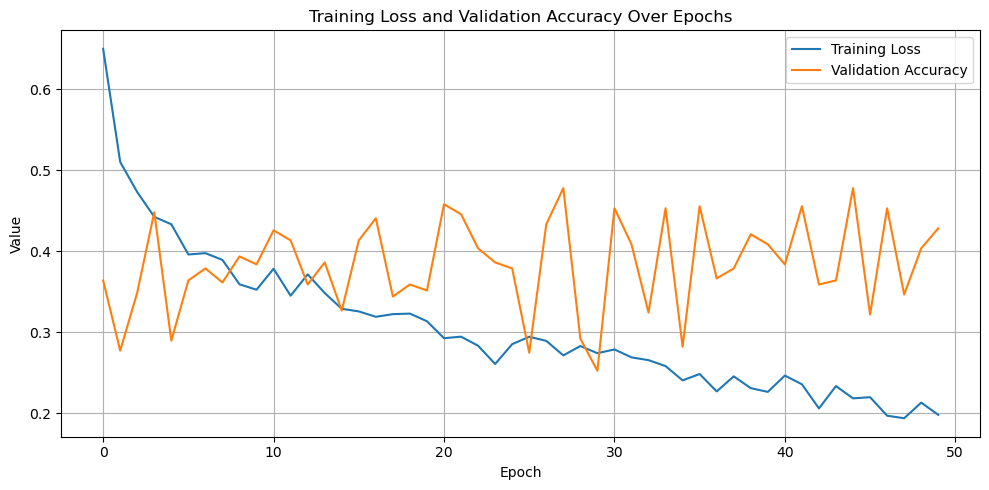

In [40]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
plt.plot(train_losses, label="Training Loss")
plt.plot(val_accuracies, label="Validation Accuracy")
plt.title("Training Loss and Validation Accuracy Over Epochs")
plt.xlabel("Epoch")
plt.ylabel("Value")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig("results/training_loss_val_accuracy.png")
plt.show()


##Observation 
This is the result of Overfittiing, Much like what Dr Zhang had suggested 
Likely that models are too large.


In [45]:
# print state dict of model 
print("Model's state_dict: ")
for param in model.state_dict():
    print(param, '\t', model.state_dict()[param].size()) 



Model's state_dict: 
firstconv.0.weight 	 torch.Size([16, 1, 1, 51])
firstconv.1.weight 	 torch.Size([16])
firstconv.1.bias 	 torch.Size([16])
firstconv.1.running_mean 	 torch.Size([16])
firstconv.1.running_var 	 torch.Size([16])
firstconv.1.num_batches_tracked 	 torch.Size([])
depthwiseConv.0.weight 	 torch.Size([32, 1, 22, 1])
depthwiseConv.1.weight 	 torch.Size([32])
depthwiseConv.1.bias 	 torch.Size([32])
depthwiseConv.1.running_mean 	 torch.Size([32])
depthwiseConv.1.running_var 	 torch.Size([32])
depthwiseConv.1.num_batches_tracked 	 torch.Size([])
separableConv.0.weight 	 torch.Size([32, 32, 1, 15])
separableConv.1.weight 	 torch.Size([32])
separableConv.1.bias 	 torch.Size([32])
separableConv.1.running_mean 	 torch.Size([32])
separableConv.1.running_var 	 torch.Size([32])
separableConv.1.num_batches_tracked 	 torch.Size([])
classify.weight 	 torch.Size([4, 992])
classify.bias 	 torch.Size([4])


In [ ]:
# Print optimizer's state_dict
print("Optimizer's state_dict:")
for var_name in optimizer.state_dict():
    print(var_name, "\t", optimizer.state_dict()[var_name])

In [53]:
import os

# Create models directory if it doesn't exist
os.makedirs('models', exist_ok=True)

# Save model state dict (this is the recommended way)
torch.save({
    'model_state_dict': model.state_dict(),
    'optimizer_state_dict': optimizer.state_dict(),
    'epoch': epoch,
    'accuracy': val_accuracy,
    'loss': loss
}, 'models/eegnet_checkpoint.pth')

In [70]:
activations = []

def hook_fn(module, input, output):
    activations.append(output.detach().cpu())

# Register hook to a specific layer (e.g., model.features[0])
hook = model.firstconv.register_forward_hook(hook_fn)

# Forward pass on a batch
model.eval()
with torch.no_grad():
    _ = model(batch_X)

# Remove hook
hook.remove()


acts = activations[0].numpy()  # Shape: (batch_size, channels, H, W)
print("Activation shape:", acts.shape)


# Convert to NumPy
acts = activations[0].numpy()  # shape: (batch_size, channels, H, W)

# Aggregate (e.g., mean over spatial dimensions and batch)
mean_acts = acts.mean(axis=(0, 2, 3))

# Plot neurons below a threshold
threshold = 0.2
low_activating = mean_acts < threshold

import matplotlib.pyplot as plt

plt.figure(figsize=(10, 4))
plt.bar(range(len(mean_acts)), mean_acts, color=["red" if low else "blue" for low in low_activating])
plt.axhline(y=threshold, color="gray", linestyle="--")
plt.title("Neuron Activations (Red = Below Threshold)")
plt.xlabel("Neuron Index")
plt.ylabel("Mean Activation")
plt.tight_layout()
plt.show()


TypeError: list indices must be integers or slices, not str

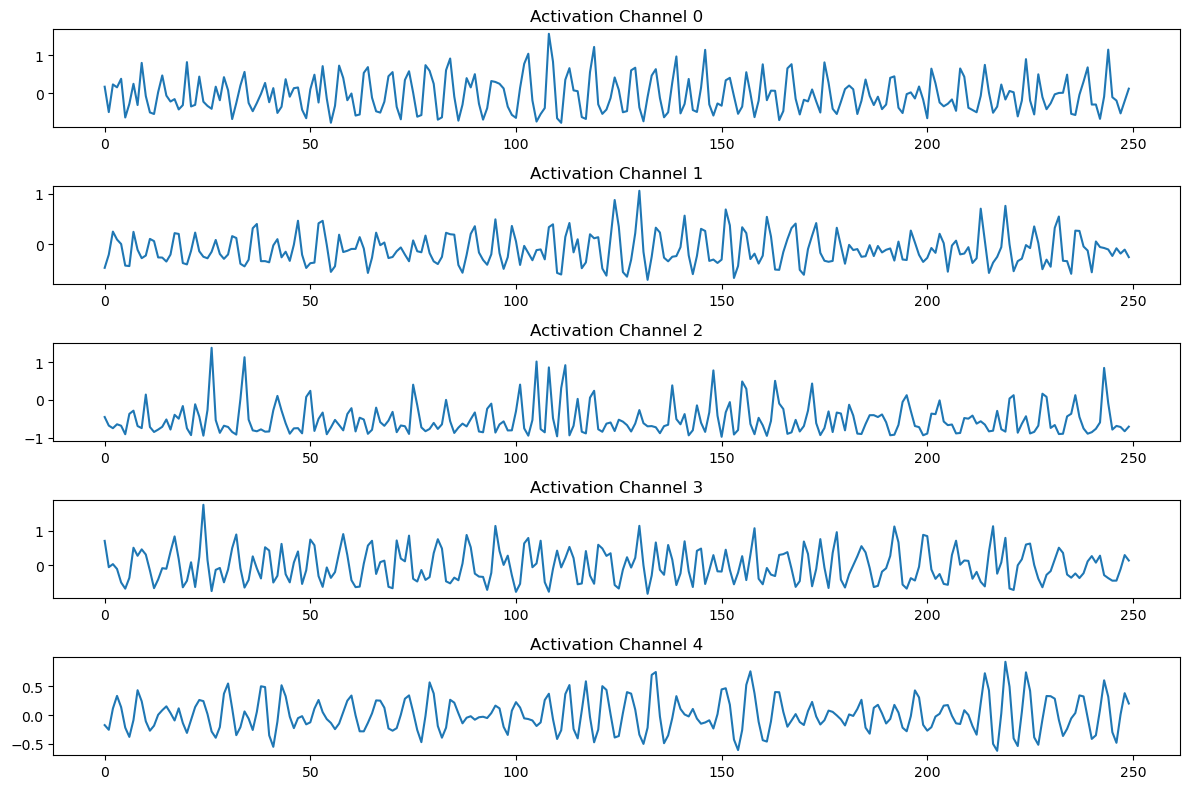

In [69]:
activations = {}

def hook_fn(name):
    def hook(module, input, output):
        activations[name] = output.detach().cpu()
    return hook

model.firstconv.register_forward_hook(hook_fn('firstconv'))
model.depthwiseConv.register_forward_hook(hook_fn('depthwise'))
model.separableConv.register_forward_hook(hook_fn('separable'))

with torch.no_grad():
    outputs = model(batch_X.to(device))
    

# Example: plot first 5 channels from 'firstconv'
act = activations['depthwise'][0]  # shape: (channels, 1, time)

fig, axs = plt.subplots(5, 1, figsize=(12, 8))
for i in range(5):
    axs[i].plot(act[i][0])  # [0] to remove singleton spatial dim
    axs[i].set_title(f'Activation Channel {i}')
plt.tight_layout()
plt.show()

